# Rancang Bangun Business Intelligence untuk Analisis Kinerja Produksi Kelapa Sawit
## Pendekatan Kimball 4-Step — Studi Kasus: PT AZ (Afdeling IX)

Alur notebook:
1. **Extract** — baca spreadsheet produksi per blok (5 sheet tahunan, 12 blok bulan per sheet)
2. **Transform** — rapikan jadi tabel 1 baris = 1 blok per bulan
3. **Load** — simpan ke data warehouse (star schema, SQLite) sesuai Kimball 4-Step
4. **Analisis statistika** — deskriptif, uji normalitas, uji korelasi (RM 1–3)

In [1]:
import re
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e6e6", "axes.edgecolor": "#999999"})
BIRU, ORANYE, HIJAU = "#2a78d6", "#eb6834", "#1baf7a"

FILE = "PRODUKSI_PER_BLOK.xlsx"   # ganti sesuai nama file di Colab

## 1. EXTRACT — membaca data mentah
Setiap sheet `IX 20xx` berisi 12 tabel bulanan yang ditumpuk ke bawah.
Tiap tabel: 37 blok + baris subtotal `Jlh` per tahun tanam + baris `Total`.
Kolom A–Q = realisasi **bulan ini**, kolom R–AC = **s/d bulan ini** (kumulatif, tidak dipakai).

In [2]:
BULAN = {"JANUARI": 1, "PEBRUARI": 2, "MARET": 3, "APRIL": 4, "MEI": 5, "JUNI": 6, "JULI": 7,
         "AGUSTUS": 8, "SEPTEMBER": 9, "OKTOBER": 10, "NOPEMBER": 11, "DESEMBER": 12}
KOLOM = ["blok", "tahun_tanam", "luas_ha", "jumlah_pokok", "sph", "rotasi_panen", "ha_panen",
         "pokok_panen", "tenaga_kerja", "janjang", "produksi_kg", "produksi_kg_pks", "_akp_teks",
         "akp_rasio", "bjr", "yield_kg_ha", "janjang_per_pokok"]

xls = pd.ExcelFile(FILE)
records = []
for sheet in [s for s in xls.sheet_names if s.strip().startswith("IX")]:
    raw = pd.read_excel(xls, sheet, header=None)
    tahun_sheet = int(sheet.split()[1])
    col_a = [str(v).strip() for v in raw.iloc[:, 0]]
    starts_all = [i for i, v in enumerate(col_a) if v.startswith("Bulan")]
    starts = starts_all[:12]                       # tabel ke-13 = rekap tahunan, dibuang
    for k, st in enumerate(starts):
        nama_bulan = re.search(r"Bulan\s*:\s*([A-Z]+)", col_a[st]).group(1)
        end = starts_all[k + 1] if k + 1 < len(starts_all) else len(raw)
        tahun_tanam = None
        for i in range(st + 4, end):
            if not re.match(r"^[A-Z]\s*\.?\s*\d+$", col_a[i]):      # lewati header, Jlh, Total, kosong
                continue
            row = dict(zip(KOLOM, raw.iloc[i, :17].tolist()))
            if pd.notna(row["tahun_tanam"]):
                tahun_tanam = int(row["tahun_tanam"])                 # merged cell → isi ke bawah
            row["tahun_tanam"] = tahun_tanam
            row.update(sheet=sheet.strip(), label_bulan=col_a[st], tahun=tahun_sheet, bulan=BULAN[nama_bulan])
            records.append(row)

stg = pd.DataFrame(records)
print("Baris hasil extract:", stg.shape)
stg.head()

Baris hasil extract: (2220, 21)


,blok,tahun_tanam,luas_ha,jumlah_pokok,sph,rotasi_panen,ha_panen,pokok_panen,tenaga_kerja,janjang,...,produksi_kg_pks,_akp_teks,akp_rasio,bjr,yield_kg_ha,janjang_per_pokok,sheet,label_bulan,tahun,bulan
0,Q. 14,1997,18.91,2447,129.40,2.00,37.82,4894,13.00,1414,...,31490,1 ;,3.46,23.78,"1,778.42",0.58,IX 2022,Bulan : JANUARI 2022,2022,1
1,Q. 16,1997,16.41,2029,123.64,2.00,32.82,4058,10.00,946,...,21940,1 ;,4.29,24.77,"1,427.79",0.47,IX 2022,Bulan : JANUARI 2022,2022,1
2,Q. 18,1997,18.70,2289,122.41,3.00,56.10,6867,17.00,1584,...,38310,1 ;,4.34,25.83,"2,187.70",0.69,IX 2022,Bulan : JANUARI 2022,2022,1
3,Q. 20,1997,17.15,2151,125.42,3.00,51.45,6453,17.00,1892,...,46280,1 ;,3.41,26.12,"2,881.63",0.88,IX 2022,Bulan : JANUARI 2022,2022,1
4,Q. 22,1997,16.60,2134,128.55,3.00,49.80,6402,13.00,1281,...,31030,1 ;,5.00,25.87,"1,996.39",0.60,IX 2022,Bulan : JANUARI 2022,2022,1


## 2. TRANSFORM — pembersihan data
Temuan saat profiling:
- Sheet `IX 2026` bulan Juli–Desember berlabel **2025** dan isinya **duplikat** 2025 → dibuang.
- Nama blok tidak konsisten (`Q .12` vs `Q. 12`) → distandarkan.
- Kolom `AKP` tersimpan sebagai teks `"1 ;"` + angka di kolom sebelahnya → diambil angkanya (AKP = 1 : x).
- Tambah kolom turunan **umur_tanaman = tahun − tahun_tanam**.
- Luas 8 blok TT 2005 berkurang mulai akhir 2025 (indikasi peremajaan/replanting) → luas disimpan
  di tabel fakta per bulan (bukan atribut tetap di dimensi) agar Yield/Ha tetap akurat.

In [3]:
df = stg.copy()
duplikat = (df["tahun"] == 2026) & (df["bulan"] > 6)
print("Baris duplikat 2026 (Jul–Des) dibuang:", duplikat.sum())
df = df[~duplikat].drop(columns=["_akp_teks", "label_bulan", "sheet"])

df["blok"] = df["blok"].str.replace(r"\s*\.\s*", ". ", regex=True).str.strip()
num_cols = [c for c in df.columns if c not in ("blok",)]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")
df["umur_tanaman"] = df["tahun"] - df["tahun_tanam"]

print("Data bersih:", df.shape, "| blok unik:", df["blok"].nunique(),
      "| periode:", f"{df.tahun.min()}-{df.bulan[df.tahun==df.tahun.min()].min():02d} s/d "
                    f"{df.tahun.max()}-{df.bulan[df.tahun==df.tahun.max()].max():02d}")
print("Missing value:\n", df.isna().sum()[df.isna().sum() > 0])
df["tenaga_kerja"] = df["tenaga_kerja"].fillna(0)

Baris duplikat 2026 (Jul–Des) dibuang: 222
Data bersih: (1998, 19) | blok unik: 37 | periode: 2022-01 s/d 2026-06
Missing value:
 tenaga_kerja    1
dtype: int64


## 3. LOAD — Data Warehouse (Kimball 4-Step)
| Step | Keputusan |
|---|---|
| 1. Pilih proses bisnis | Realisasi produksi panen TBS per blok |
| 2. Deklarasi grain | **1 baris fakta = 1 blok pada 1 bulan** |
| 3. Identifikasi dimensi | `dim_waktu`, `dim_blok` (afdeling, tahun tanam, luas awal) |
| 4. Identifikasi fakta | luas_ha, produksi_kg, janjang, BJR, SPH, yield_kg_ha, rotasi, ha_panen, TK, umur_tanaman, dll. |

In [4]:
dim_waktu = (df[["tahun", "bulan"]].drop_duplicates().sort_values(["tahun", "bulan"]).reset_index(drop=True))
dim_waktu.insert(0, "waktu_key", dim_waktu["tahun"] * 100 + dim_waktu["bulan"])
dim_waktu["kuartal"] = (dim_waktu["bulan"] - 1) // 3 + 1
dim_waktu["semester"] = np.where(dim_waktu["bulan"] <= 6, 1, 2)
dim_waktu["nama_bulan"] = dim_waktu["bulan"].map({v: k.title() for k, v in BULAN.items()})

dim_blok = (df.groupby("blok", as_index=False)
              .agg(tahun_tanam=("tahun_tanam", "first"), luas_awal_ha=("luas_ha", "first"))
              .sort_values(["tahun_tanam", "blok"]).reset_index(drop=True))
dim_blok.insert(0, "blok_key", range(1, len(dim_blok) + 1))
dim_blok.insert(2, "afdeling", "IX")
dim_blok.insert(3, "estate", "PT AZ")

fakta_cols = ["luas_ha", "jumlah_pokok", "sph", "rotasi_panen", "ha_panen", "pokok_panen", "tenaga_kerja",
              "janjang", "produksi_kg", "produksi_kg_pks", "akp_rasio", "bjr", "yield_kg_ha",
              "janjang_per_pokok", "umur_tanaman"]
fact_produksi = (df.assign(waktu_key=df["tahun"] * 100 + df["bulan"])
                   .merge(dim_blok[["blok_key", "blok"]], on="blok")
                   [["waktu_key", "blok_key"] + fakta_cols])

con = sqlite3.connect("dw_produksi_sawit.db")
dim_waktu.to_sql("dim_waktu", con, if_exists="replace", index=False)
dim_blok.to_sql("dim_blok", con, if_exists="replace", index=False)
fact_produksi.to_sql("fact_produksi", con, if_exists="replace", index=False)
for t in ["dim_waktu", "dim_blok", "fact_produksi"]:
    print(t, pd.read_sql(f"SELECT COUNT(*) n FROM {t}", con).n[0], "baris")

dim_waktu 54 baris
dim_blok 37 baris
fact_produksi 1998 baris


### Dataset analisis (query dari data warehouse)
Yield/Ha di industri sawit lazim dinyatakan **ton TBS/ha/tahun**, jadi data diagregasi ke
**blok-tahun** untuk tahun yang lengkap 12 bulan (2022–2025) → 37 blok × 4 tahun = **148 sampel**.

In [5]:
q = """
SELECT w.tahun, b.blok, b.tahun_tanam,
       AVG(f.luas_ha)                     AS luas_ha,
       AVG(f.sph)                         AS sph,
       MAX(f.umur_tanaman)                AS umur_tanaman,
       SUM(f.produksi_kg)                 AS produksi_kg,
       SUM(f.janjang)                     AS janjang,
       SUM(f.produksi_kg / f.luas_ha) / 1000.0 AS yield_ton_ha
FROM fact_produksi f
JOIN dim_waktu w ON f.waktu_key = w.waktu_key
JOIN dim_blok  b ON f.blok_key  = b.blok_key
GROUP BY w.tahun, b.blok
HAVING COUNT(*) = 12
ORDER BY w.tahun, b.blok
"""
data = pd.read_sql(q, con)
data["bjr"] = data["produksi_kg"] / data["janjang"]
data.to_csv("dataset_analisis_blok_tahun.csv", index=False)
print(data.shape)
data.head()

(148, 10)


,tahun,blok,tahun_tanam,luas_ha,sph,umur_tanaman,produksi_kg,janjang,yield_ton_ha,bjr
0,2022,L. 10,2005,0.83,118.07,17,20350,976,24.52,20.85
1,2022,M. 10,2005,10.08,115.08,17,295570,14301,29.32,20.67
2,2022,M. 12,1997,12.81,128.10,25,351030,15361,27.40,22.85
3,2022,M. 14,1997,2.22,125.23,25,80840,3327,36.41,24.30
4,2022,M. 16,2005,0.86,129.07,17,26830,1188,31.20,22.58


## 4. RM 1 — Statistika Deskriptif Yield/Ha, SPH, Umur Tanaman

In [6]:
VAR = {"yield_ton_ha": "Yield (ton/ha/tahun)", "sph": "SPH (pokok/ha)", "umur_tanaman": "Umur Tanaman (tahun)"}

def deskriptif(s):
    return pd.Series({
        "n": s.count(), "Mean": s.mean(), "Median": s.median(), "Modus": s.mode().iloc[0] if s.duplicated().any() else np.nan,
        "Std. Deviasi": s.std(), "Varians": s.var(), "Min": s.min(), "Q1": s.quantile(.25),
        "Q3": s.quantile(.75), "Max": s.max(), "Range": s.max() - s.min(),
        "IQR": s.quantile(.75) - s.quantile(.25), "Koef. Variasi (%)": s.std() / s.mean() * 100,
        "Skewness": s.skew(), "Kurtosis": s.kurt()})

tabel_desk = data[list(VAR)].apply(deskriptif).rename(columns=VAR)
tabel_desk.to_csv("tabel_statistik_deskriptif.csv")
tabel_desk

,Yield (ton/ha/tahun),SPH (pokok/ha),Umur Tanaman (tahun)
n,148.00,148.00,148.00
Mean,25.95,123.25,24.26
Median,26.02,124.85,25.00
Modus,NaN,107.77,25.00
Std. Deviasi,3.38,9.19,3.49
Varians,11.46,84.41,12.16
Min,16.86,97.12,17.00
Q1,24.19,121.38,24.00
Q3,27.87,128.68,27.00
Max,36.41,138.51,28.00


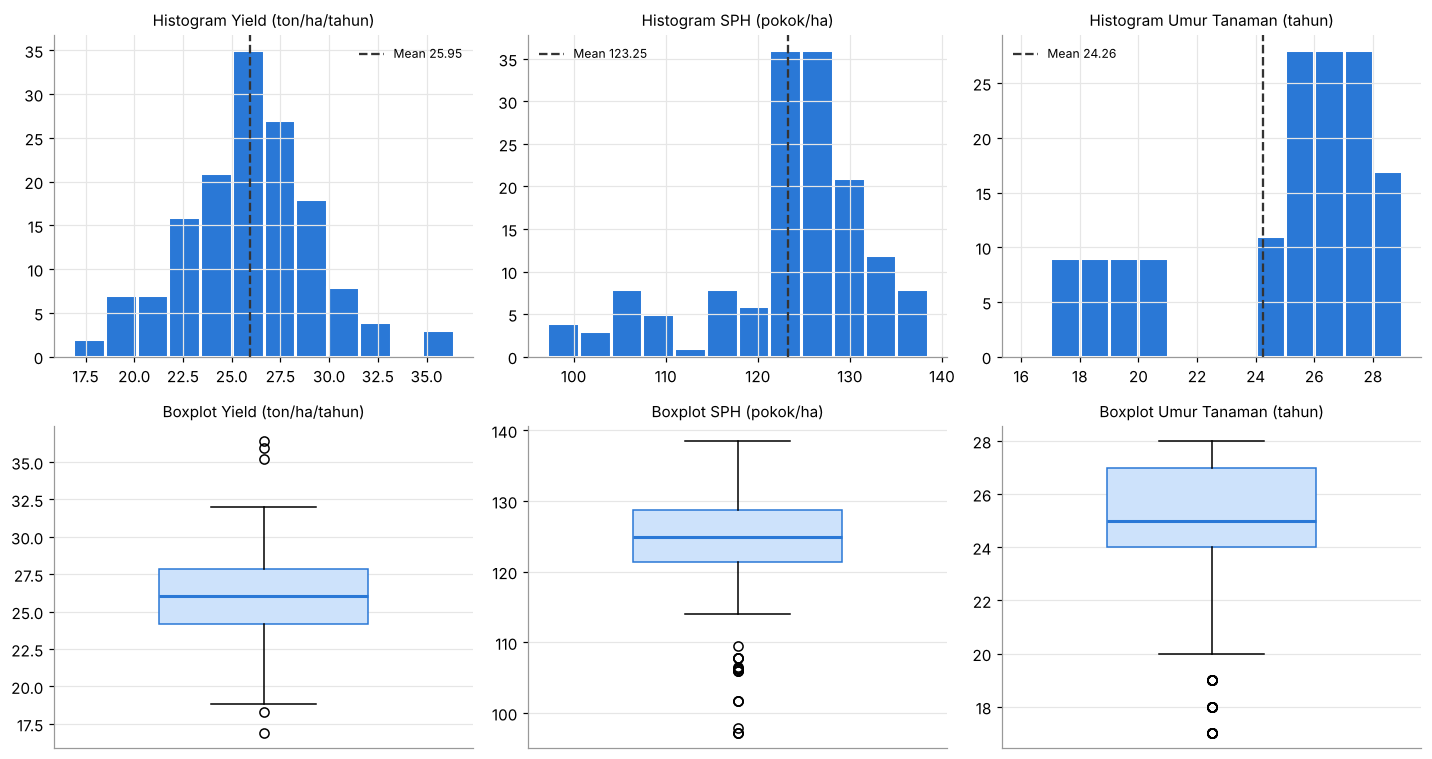

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for j, (col, nama) in enumerate(VAR.items()):
    axes[0, j].hist(data[col], bins=12 if col != "umur_tanaman" else range(16, 30),
                    color=BIRU, edgecolor="white", linewidth=2)
    axes[0, j].axvline(data[col].mean(), color="#333", ls="--", lw=1.5, label=f"Mean {data[col].mean():.2f}")
    axes[0, j].set_title(f"Histogram {nama}", fontsize=10); axes[0, j].legend(fontsize=8, frameon=False)
    axes[1, j].boxplot(data[col], widths=.5, patch_artist=True,
                       boxprops=dict(facecolor="#cde2fb", edgecolor=BIRU), medianprops=dict(color=BIRU, lw=2))
    axes[1, j].set_title(f"Boxplot {nama}", fontsize=10); axes[1, j].set_xticks([])
plt.tight_layout(); plt.savefig("gambar_1_distribusi.png", bbox_inches="tight"); plt.show()

### Tambahan: Yield per kelompok tahun tanam & tren tahunan

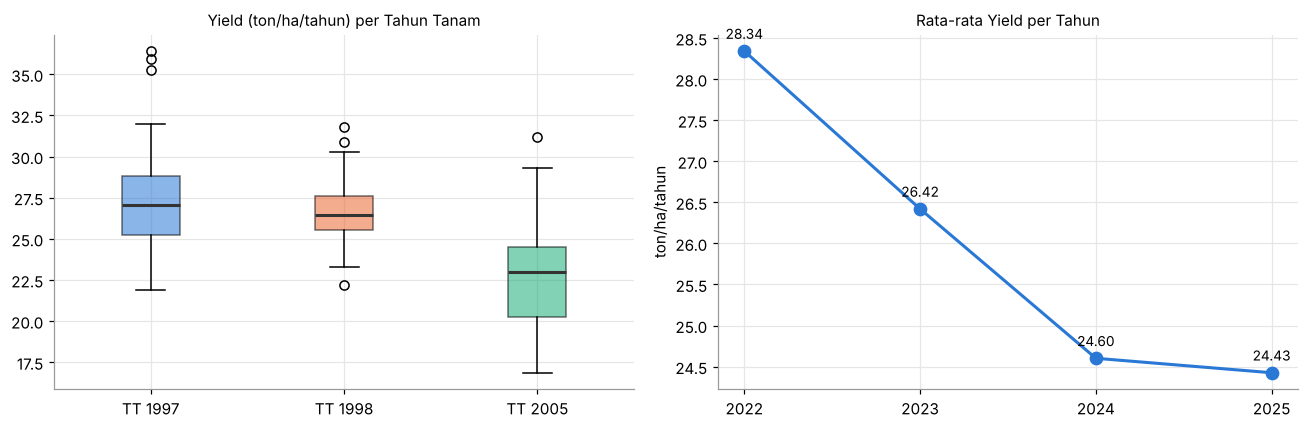

             count  mean  std   min   25%   50%   75%   max
tahun_tanam                                                
1997         68.00 27.25 3.08 21.88 25.23 27.08 28.84 36.41
1998         44.00 26.65 2.04 22.18 25.53 26.46 27.62 31.79
2005         36.00 22.63 3.11 16.86 20.27 23.01 24.50 31.20


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
grp = [data.loc[data.tahun_tanam == t, "yield_ton_ha"] for t in sorted(data.tahun_tanam.unique())]
bp = ax[0].boxplot(grp, patch_artist=True, medianprops=dict(color="#333", lw=2))
ax[0].set_xticks(range(1, len(grp) + 1), [f"TT {t}" for t in sorted(data.tahun_tanam.unique())])
for p, c in zip(bp["boxes"], [BIRU, ORANYE, HIJAU]):
    p.set_facecolor(c); p.set_alpha(.55)
ax[0].set_title("Yield (ton/ha/tahun) per Tahun Tanam", fontsize=10)
tren = data.groupby("tahun")["yield_ton_ha"].mean()
ax[1].plot(tren.index, tren.values, marker="o", ms=8, lw=2, color=BIRU)
for x, y in tren.items():
    ax[1].annotate(f"{y:.2f}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
ax[1].set_xticks(tren.index); ax[1].set_title("Rata-rata Yield per Tahun", fontsize=10)
ax[1].set_ylabel("ton/ha/tahun")
plt.tight_layout(); plt.savefig("gambar_2_tahun_tanam_tren.png", bbox_inches="tight"); plt.show()
print(data.groupby("tahun_tanam")["yield_ton_ha"].describe())

### Blok produksi rendah (yield < Q1) — jawaban "blok rendah sulit diketahui"

In [9]:
q1 = data["yield_ton_ha"].quantile(.25)
rendah = (data[data["yield_ton_ha"] < q1].groupby(["blok", "tahun_tanam", "luas_ha"])
          .agg(kali_di_bawah_Q1=("tahun", "count"), rata2_yield=("yield_ton_ha", "mean"))
          .sort_values(["kali_di_bawah_Q1", "rata2_yield"], ascending=[False, True]).reset_index())
print(f"Q1 yield = {q1:.2f} ton/ha/tahun")
rendah.head(10)

Q1 yield = 24.19 ton/ha/tahun


,blok,tahun_tanam,luas_ha,kali_di_bawah_Q1,rata2_yield
0,P. 26,2005,4.76,4,22.30
1,P. 12,2005,9.39,3,19.69
2,Q. 10,2005,5.16,3,21.08
3,N. 10,2005,10.83,3,21.10
4,M. 16,2005,0.86,2,20.97
5,L. 10,2005,0.83,2,21.26
6,Q. 26,2005,4.38,2,22.01
7,P. 14,1997,14.28,2,22.49
8,M. 12,1997,12.81,2,22.61
9,N. 12,1998,16.18,2,22.73


## 5. Uji Normalitas (Shapiro-Wilk, α = 0,05)
H0: data berdistribusi normal · H1: data tidak berdistribusi normal

In [10]:
norm = []
for col, nama in VAR.items():
    w, p = stats.shapiro(data[col])
    norm.append([nama, w, p, "Normal" if p > .05 else "Tidak normal"])
norm = pd.DataFrame(norm, columns=["Variabel", "W", "p-value", "Kesimpulan"])
norm

,Variabel,W,p-value,Kesimpulan
0,Yield (ton/ha/tahun),0.99,0.15,Normal
1,SPH (pokok/ha),0.90,0.00,Tidak normal
2,Umur Tanaman (tahun),0.81,0.00,Tidak normal


Karena **SPH dan Umur Tanaman tidak berdistribusi normal** (umur hanya punya sedikit nilai diskrit),
uji korelasi utama memakai **Spearman Rank** (non-parametrik). Pearson ditampilkan sebagai pembanding.

## 6. RM 2 & RM 3 — Uji Korelasi (α = 0,05)
- RM 2 → H0: ρ = 0 (tidak ada hubungan Umur Tanaman dengan Yield/Ha) · H1: ρ ≠ 0
- RM 3 → H0: ρ = 0 (tidak ada hubungan SPH dengan Yield/Ha) · H1: ρ ≠ 0

Interpretasi kekuatan |r|: 0–0,19 sangat lemah · 0,20–0,39 lemah · 0,40–0,59 sedang · 0,60–0,79 kuat · 0,80–1 sangat kuat

In [11]:
def kekuatan(r):
    r = abs(r)
    return ("sangat lemah" if r < .2 else "lemah" if r < .4 else "sedang" if r < .6
            else "kuat" if r < .8 else "sangat kuat")

hasil = []
for x in ["umur_tanaman", "sph"]:
    rs, ps = stats.spearmanr(data[x], data["yield_ton_ha"])
    rp, pp = stats.pearsonr(data[x], data["yield_ton_ha"])
    hasil.append([VAR[x] + " vs Yield", rs, ps, kekuatan(rs), "Tolak H0 (signifikan)" if ps < .05 else "Gagal tolak H0",
                  rp, pp])
hasil = pd.DataFrame(hasil, columns=["Pasangan", "Spearman ρ", "p-value", "Kekuatan", "Keputusan",
                                     "Pearson r", "p-value (Pearson)"])
hasil.to_csv("tabel_uji_korelasi.csv", index=False)
hasil

,Pasangan,Spearman ρ,p-value,Kekuatan,Keputusan,Pearson r,p-value (Pearson)
0,Umur Tanaman (tahun) vs Yield,0.12,0.14,sangat lemah,Gagal tolak H0,0.39,0.00
1,SPH (pokok/ha) vs Yield,0.43,0.00,sedang,Tolak H0 (signifikan),0.49,0.00


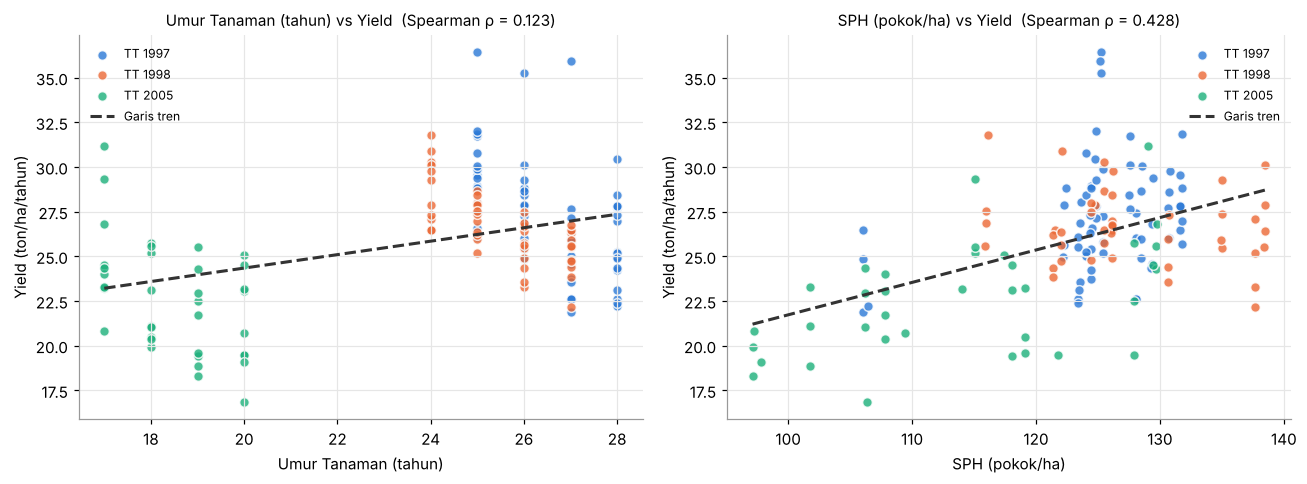

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, x in zip(axes, ["umur_tanaman", "sph"]):
    for t, c in zip(sorted(data.tahun_tanam.unique()), [BIRU, ORANYE, HIJAU]):
        d = data[data.tahun_tanam == t]
        ax.scatter(d[x], d["yield_ton_ha"], s=40, color=c, alpha=.8, edgecolor="white", lw=1, label=f"TT {t}")
    m, b = np.polyfit(data[x], data["yield_ton_ha"], 1)
    xs = np.linspace(data[x].min(), data[x].max(), 50)
    ax.plot(xs, m * xs + b, color="#333", lw=2, ls="--", label="Garis tren")
    r = hasil.loc[hasil.Pasangan.str.startswith(VAR[x]), "Spearman ρ"].iloc[0]
    ax.set_title(f"{VAR[x]} vs Yield  (Spearman ρ = {r:.3f})", fontsize=10)
    ax.set_xlabel(VAR[x]); ax.set_ylabel("Yield (ton/ha/tahun)"); ax.legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.savefig("gambar_3_scatter_korelasi.png", bbox_inches="tight"); plt.show()

### Catatan pembahasan: kenapa Pearson & Spearman umur berbeda?
Umur tanaman hanya berasal dari 3 tahun tanam (1997, 1998, 2005). Antar-kelompok, blok tua
(TT 1997/1998) yield-nya lebih tinggi dari TT 2005. Tapi **di dalam** kelompok yang sama, makin
bertambah umur (2022→2025) yield justru turun. Dua pola berlawanan ini membuat korelasi peringkat
(Spearman) lemah & tidak signifikan, sementara Pearson terdorong oleh selisih antar-kelompok.

In [13]:
for t in sorted(data.tahun_tanam.unique()):
    d = data[data.tahun_tanam == t]
    rs, ps = stats.spearmanr(d["umur_tanaman"], d["yield_ton_ha"])
    print(f"TT {t}: Spearman umur vs yield (dalam kelompok) ρ = {rs:.3f}, p = {ps:.4f}")

TT 1997: Spearman umur vs yield (dalam kelompok) ρ = -0.588, p = 0.0000
TT 1998: Spearman umur vs yield (dalam kelompok) ρ = -0.724, p = 0.0000
TT 2005: Spearman umur vs yield (dalam kelompok) ρ = -0.471, p = 0.0037


## 7. Ringkasan hasil

In [14]:
d = tabel_desk
print(f"""RM1  Yield rata-rata {d.loc['Mean', VAR['yield_ton_ha']]:.2f} ton/ha/tahun (SD {d.loc['Std. Deviasi', VAR['yield_ton_ha']]:.2f}, \
rentang {d.loc['Min', VAR['yield_ton_ha']]:.2f}–{d.loc['Max', VAR['yield_ton_ha']]:.2f});
     SPH rata-rata {d.loc['Mean', VAR['sph']]:.2f} pokok/ha (median {d.loc['Median', VAR['sph']]:.2f});
     Umur tanaman rata-rata {d.loc['Mean', VAR['umur_tanaman']]:.2f} tahun (rentang {d.loc['Min', VAR['umur_tanaman']]:.0f}–{d.loc['Max', VAR['umur_tanaman']]:.0f}).""")
for _, r in hasil.iterrows():
    print(f"{r.Pasangan}: ρ = {r['Spearman ρ']:.3f}, p = {r['p-value']:.4g} → {r.Keputusan}, hubungan {r.Kekuatan}")

RM1  Yield rata-rata 25.95 ton/ha/tahun (SD 3.38, rentang 16.86–36.41);
     SPH rata-rata 123.25 pokok/ha (median 124.85);
     Umur tanaman rata-rata 24.26 tahun (rentang 17–28).
Umur Tanaman (tahun) vs Yield: ρ = 0.123, p = 0.138 → Gagal tolak H0, hubungan sangat lemah
SPH (pokok/ha) vs Yield: ρ = 0.428, p = 5.861e-08 → Tolak H0 (signifikan), hubungan sedang
